# Seed viability model

This notebook provides a **literature-benchmarked simulation and modelling workflow** for seed viability, germination, and dormancy under storage. It is designed as a **proof of concept**, not as a replacement for real genebank, breeding, or seed physiology experiments.

## What this notebook does

It simulates longitudinal seed-lot data using parameter ranges grounded in the seed longevity literature, then performs:

1. data generation for orthodox, intermediate, and recalcitrant seed lots,
2. explicit separation of **viability**, **germination**, and **dormancy** endpoints,
3. storage-risk modelling using a **survival-style discrete-time hazard framework**,
4. hybrid modelling using a **mechanistic baseline + machine-learning residual learner**,
5. visualisation of trajectories and risk landscapes,
6. export of publishable figures and tables.

## Literature anchors used for benchmarking

The simulation ranges and modelling assumptions are benchmarked against widely cited seed-storage literature and reviews, including the following themes:

- The **Ellis-Roberts seed viability framework**, where longevity depends strongly on moisture content and temperature under hermetic storage.
- For **orthodox seeds**, genebank guidance commonly targets **low moisture content, roughly 3–7%**, and **low temperature around −18 to −20 °C** for long-term conservation.
- Under **ambient storage**, half-life can be relatively short, often around **5–10 years**, whereas under improved low-humidity and low-temperature conditions it can extend to **40–60 years**, and sometimes longer in genebank conditions.
- For **recalcitrant seeds**, viability often collapses below a species-specific **critical moisture content**, with published examples spanning roughly **23% to >60% moisture content**, and storage is best near fully hydrated conditions above the chilling-injury threshold.
- Oxygen matters. Published work shows that **high oxygen accelerates ageing**, whereas **anoxia or very low oxygen can preserve longevity** under suitable dry-storage conditions.

## Key references

Ellis and Roberts established the classical viability equations. Hay and colleagues reviewed moisture isotherms and viability equations. Solberg and colleagues summarised long-term orthodox seed longevity. Reed and colleagues reviewed seed vigor, dormancy, and climate interactions. Hong and Ellis provided a practical protocol for determining seed storage behaviour. Groot and colleagues showed that elevated oxygen accelerates ageing and that anoxia can be beneficial under dry storage.

This notebook includes a compact reference list at the end.

In [2]:
# Core imports
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    mean_absolute_error, mean_squared_error, r2_score, log_loss
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.calibration import calibration_curve

np.random.seed(42)

ROOT = Path.cwd()
OUTDIR = ROOT / "seed_viability_outputs"
FIGDIR = OUTDIR / "figures"
TABDIR = OUTDIR / "tables"

for d in [OUTDIR, FIGDIR, TABDIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Output directory:", OUTDIR.resolve())

Output directory: /Users/petalc01/ARIA Recalcitrant Seeds/seed_viability_outputs


## Biological rationale behind the simulation

Real seed-lot ageing depends on species, developmental history, moisture status, storage atmosphere, temperature, packaging, oxygen, and assay choice. A major practical issue is that **germination is not identical to viability**, and **dormancy can mask viability**. This notebook therefore keeps three related but distinct endpoints:

- **viability**, meaning the seed remains alive,
- **germination**, meaning the seed produces a normal seedling in the assay,
- **dormancy**, meaning a viable seed remains ungerminated because dormancy persists.

This distinction is important in seed banks, restoration biology, and crop seed systems.

In [5]:
def logistic(x):
    return 1.0 / (1.0 + np.exp(-x))

def probit_like_survival(z):
    return logistic(1.702 * z)

def bounded_normal(mean, sd, low, high, n):
    x = np.random.normal(mean, sd, n)
    return np.clip(x, low, high)

def category_params(category):
    if category == "orthodox":
        return {"mc_mean": 6.0, "mc_sd": 1.2, "mc_low": 3.0, "mc_high": 10.0,
                "temp_mean": 5.0, "temp_sd": 12.0, "temp_low": -20.0, "temp_high": 35.0}
    elif category == "intermediate":
        return {"mc_mean": 12.0, "mc_sd": 2.0, "mc_low": 8.0, "mc_high": 18.0,
                "temp_mean": 12.0, "temp_sd": 8.0, "temp_low": 0.0, "temp_high": 30.0}
    else:
        return {"mc_mean": 38.0, "mc_sd": 9.0, "mc_low": 20.0, "mc_high": 70.0,
                "temp_mean": 18.0, "temp_sd": 6.0, "temp_low": 5.0, "temp_high": 30.0}

species_catalog = [
    ("barley", "orthodox"),
    ("rice", "orthodox"),
    ("soybean", "orthodox"),
    ("lettuce", "orthodox"),
    ("coffee", "intermediate"),
    ("citrus", "intermediate"),
    ("neem", "intermediate"),
    ("oak", "recalcitrant"),
    ("cocoa", "recalcitrant"),
    ("avicennia", "recalcitrant"),
]

## Mechanistic structure used for simulation

The simulator uses a **viability-equation-inspired latent deterioration score**. It is not intended to reproduce any one exact experimental paper. Instead, it encodes the broad literature consensus that lower temperature generally prolongs longevity, lower moisture prolongs longevity for orthodox seeds, recalcitrant seeds are damaged by drying below a safe threshold, oxygen accelerates deterioration in storage, poor initial lot quality increases failure risk, and dormancy can initially decline during after-ripening before deep ageing reduces germination.

In [8]:
def simulate_seed_data(n_lots=180, n_timepoints=8):
    records = []
    lot_rows = []
    lot_id = 0

    oxygen_levels = ["anoxic", "low", "ambient", "high"]
    packages = ["foil_hermetic", "jar_hermetic", "paper", "laminate"]
    endpoints = np.array([0, 3, 6, 12, 24, 36, 60, 84], dtype=float)

    for _ in range(n_lots):
        species, category = species_catalog[np.random.randint(0, len(species_catalog))]
        p = category_params(category)
        lot_id += 1
        lot = f"LOT_{lot_id:03d}"

        initial_viability = float(np.clip(np.random.normal(0.94, 0.035), 0.80, 0.995))
        primary_dormancy = float(np.clip(np.random.beta(2.2, 4.5), 0.02, 0.70))
        seed_fill_stress = float(np.clip(np.random.beta(2.0, 5.0), 0.0, 1.0))
        mechanical_damage = float(np.clip(np.random.beta(1.5, 8.0), 0.0, 0.5))
        fungal_pressure = float(np.clip(np.random.beta(1.7, 6.5), 0.0, 0.6))

        mc = float(bounded_normal(p["mc_mean"], p["mc_sd"], p["mc_low"], p["mc_high"], 1)[0])
        temp = float(bounded_normal(p["temp_mean"], p["temp_sd"], p["temp_low"], p["temp_high"], 1)[0])
        oxygen = np.random.choice(oxygen_levels, p=[0.18, 0.24, 0.45, 0.13])
        package = np.random.choice(packages, p=[0.30, 0.18, 0.32, 0.20])

        if category == "orthodox":
            aw = np.clip(0.18 + 0.035 * mc + np.random.normal(0, 0.03), 0.12, 0.75)
            critical_mc = np.nan
        elif category == "intermediate":
            aw = np.clip(0.40 + 0.020 * mc + np.random.normal(0, 0.04), 0.30, 0.92)
            critical_mc = float(np.clip(np.random.normal(12.5, 2.5), 8.0, 18.0))
        else:
            aw = np.clip(0.72 + 0.004 * mc + np.random.normal(0, 0.03), 0.75, 0.99)
            critical_mc = float(np.clip(np.random.normal(36.0, 10.0), 20.0, 62.0))

        lot_rows.append({
            "lot_id": lot, "species": species, "category": category,
            "initial_viability": initial_viability, "primary_dormancy": primary_dormancy,
            "seed_fill_stress": seed_fill_stress, "mechanical_damage": mechanical_damage,
            "fungal_pressure": fungal_pressure, "storage_moisture_pct": mc,
            "storage_temp_c": temp, "oxygen_level": oxygen, "package_type": package,
            "water_activity": aw, "critical_moisture_pct": critical_mc,
        })

        lot_quality = (
            2.6 + 2.2 * (initial_viability - 0.90) - 1.1 * seed_fill_stress
            - 1.0 * mechanical_damage - 0.6 * fungal_pressure + np.random.normal(0, 0.20)
        )

        for month in endpoints[:n_timepoints]:
            oxygen_penalty = {"anoxic": -0.12, "low": -0.06, "ambient": 0.00, "high": 0.20}[oxygen]
            package_penalty = {"foil_hermetic": -0.08, "jar_hermetic": -0.05, "paper": 0.08, "laminate": 0.00}[package]

            if category == "orthodox":
                mc_term = 0.055 * (mc - 6.0)
                temp_term = 0.020 * (temp + 5.0)
                desiccation_penalty = 0.0
                recalc_penalty = 0.0
            elif category == "intermediate":
                mc_term = 0.050 * abs(mc - 12.0)
                temp_term = 0.024 * max(temp - 10.0, 0.0)
                desiccation_penalty = 0.12 * max(10.0 - mc, 0.0)
                recalc_penalty = 0.0
            else:
                mc_term = -0.010 * max(mc - 45.0, 0.0)
                temp_term = 0.030 * abs(temp - 18.0)
                desiccation_penalty = 0.18 * max((critical_mc - mc), 0.0) / 5.0 if not np.isnan(critical_mc) else 0.0
                recalc_penalty = 0.15 * max(8.0 - temp, 0.0) / 3.0

            aw_term = 0.45 * max(aw - 0.65, 0.0)
            elapsed = month / 12.0
            deterioration_rate = max(
                0.02,
                0.18 + mc_term + temp_term + oxygen_penalty + package_penalty + aw_term +
                desiccation_penalty + recalc_penalty + 0.15 * fungal_pressure
            )

            latent_viability = lot_quality - deterioration_rate * elapsed + np.random.normal(0, 0.10)
            viability_prob = float(np.clip(probit_like_survival(latent_viability - 0.6), 0.001, 0.999))

            dormancy_signal = (
                1.8 * primary_dormancy - 0.9 * np.log1p(month) / np.log(13) +
                0.25 * seed_fill_stress + 0.12 * (category == "orthodox") + np.random.normal(0, 0.08)
            )
            dormancy_prob = float(np.clip(logistic(dormancy_signal), 0.001, 0.95))
            dormancy_prob = min(dormancy_prob, viability_prob * 0.98)

            ageing_germ_penalty = 0.10 * elapsed + 0.20 * max(aw - 0.75, 0.0)
            germination_prob = float(np.clip(viability_prob * (1 - dormancy_prob) * (1 - ageing_germ_penalty), 0.0005, 0.999))
            abnormal_seedling_prob = float(np.clip((viability_prob - germination_prob) * 0.60, 0.0, viability_prob))
            n_test = 100
            viable_count = np.random.binomial(n_test, viability_prob)
            germ_count = np.random.binomial(n_test, min(germination_prob / max(viability_prob, 1e-6), 1.0)) if viable_count > 0 else 0
            germ_count = min(germ_count, viable_count)
            dormant_count = max(viable_count - germ_count, 0)

            records.append({
                "lot_id": lot, "species": species, "category": category, "month": month,
                "storage_years": month / 12.0, "initial_viability": initial_viability,
                "primary_dormancy": primary_dormancy, "seed_fill_stress": seed_fill_stress,
                "mechanical_damage": mechanical_damage, "fungal_pressure": fungal_pressure,
                "storage_moisture_pct": mc, "storage_temp_c": temp, "oxygen_level": oxygen,
                "package_type": package, "water_activity": aw, "critical_moisture_pct": critical_mc,
                "viability_prob": viability_prob, "germination_prob": germination_prob,
                "dormancy_prob": dormancy_prob, "abnormal_seedling_prob": abnormal_seedling_prob,
                "viable_count": viable_count, "germinated_count": germ_count,
                "dormant_count": dormant_count, "dead_count": n_test - viable_count,
                "n_tested": n_test,
            })
    return pd.DataFrame(records), pd.DataFrame(lot_rows)

df, lots = simulate_seed_data()
print(df.shape, lots.shape)
df.head()

(1440, 25) (180, 14)


,lot_id,species,category,month,storage_years,initial_viability,primary_dormancy,seed_fill_stress,mechanical_damage,fungal_pressure,...,critical_moisture_pct,viability_prob,germination_prob,dormancy_prob,abnormal_seedling_prob,viable_count,germinated_count,dormant_count,dead_count,n_tested
0,LOT_001,neem,intermediate,0.0,0.00,0.920742,0.551164,0.675136,0.085183,0.125077,...,13.055197,0.846550,0.202335,0.760988,0.386529,85,29,56,15,100
1,LOT_001,neem,intermediate,3.0,0.25,0.920742,0.551164,0.675136,0.085183,0.125077,...,13.055197,0.813795,0.241352,0.695820,0.343466,90,37,53,10,100
2,LOT_001,neem,intermediate,6.0,0.50,0.920742,0.551164,0.675136,0.085183,0.125077,...,13.055197,0.750257,0.257857,0.638219,0.295440,84,37,47,16,100
3,LOT_001,neem,intermediate,12.0,1.00,0.920742,0.551164,0.675136,0.085183,0.125077,...,13.055197,0.797025,0.290054,0.595644,0.304183,76,36,40,24,100
4,LOT_001,neem,intermediate,24.0,2.00,0.920742,0.551164,0.675136,0.085183,0.125077,...,13.055197,0.695388,0.281622,0.493768,0.248259,74,37,37,26,100


## Quick inspection of the simulated data

In [11]:
summary = df.groupby("category")[["viability_prob", "germination_prob", "dormancy_prob", "storage_moisture_pct", "storage_temp_c"]].agg(["mean", "std"])
summary.round(3)

viability_prob        germination_prob        dormancy_prob  \
                       mean    std             mean    std          mean   
category                                                                   
intermediate          0.686  0.292            0.290  0.146         0.414   
orthodox              0.713  0.300            0.296  0.148         0.417   
recalcitrant          0.597  0.353            0.249  0.156         0.379   

                    storage_moisture_pct         storage_temp_c          
                std                 mean     std           mean     std  
category                                                                 
intermediate  0.183               11.526   2.052         11.562   8.099  
orthodox      0.187                5.944   1.194          4.094  12.493  
recalcitrant  0.218               36.899  10.063         18.563   5.540

In [13]:
lot_table = lots.copy().round(4)
time_table = df.groupby(["category", "month"])[["viability_prob", "germination_prob", "dormancy_prob"]].mean().reset_index().round(4)
lot_table.to_csv(TABDIR / "table_1_simulated_seed_lots.csv", index=False)
time_table.to_csv(TABDIR / "table_2_mean_trajectories_by_category.csv", index=False)
print("Saved descriptive tables.")

Saved descriptive tables.


## Visualisation 1, endpoint separation over time

This figure shows why a single germination score can be misleading. A decline in germination may reflect either true viability loss or persistent dormancy.

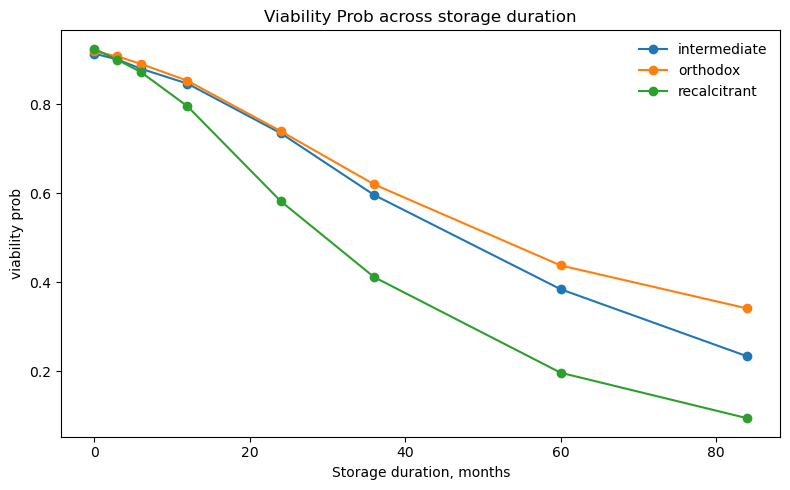

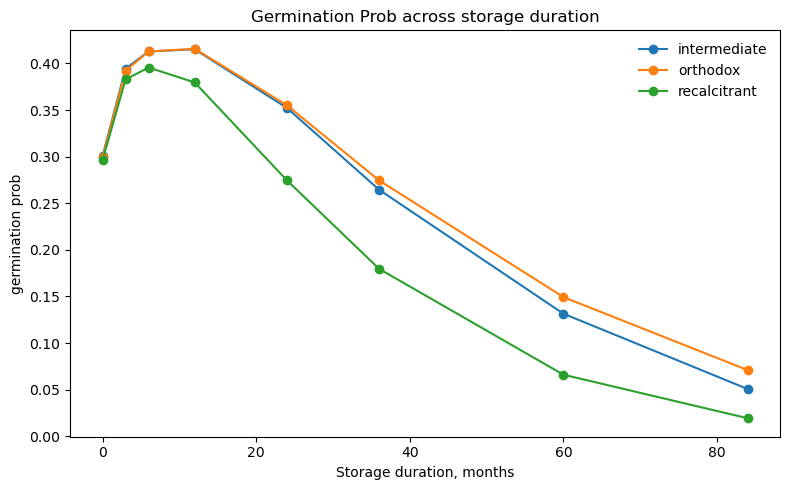

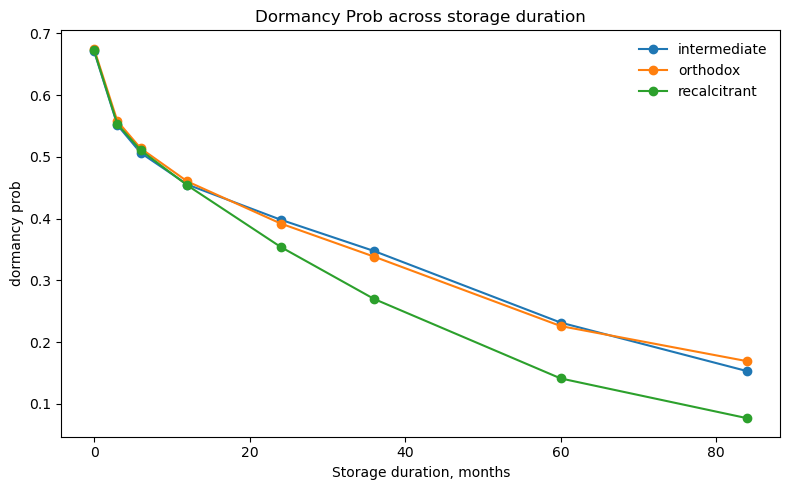

In [16]:
plot_df = df.groupby(["month", "category"])[["viability_prob", "germination_prob", "dormancy_prob"]].mean().reset_index()

for metric in ["viability_prob", "germination_prob", "dormancy_prob"]:
    fig, ax = plt.subplots(figsize=(8, 5))
    for cat in plot_df["category"].unique():
        sub = plot_df[plot_df["category"] == cat]
        ax.plot(sub["month"], sub[metric], marker="o", label=cat)
    ax.set_xlabel("Storage duration, months")
    ax.set_ylabel(metric.replace("_", " "))
    ax.set_title(f"{metric.replace('_', ' ').title()} across storage duration")
    ax.legend(frameon=False)
    fig.tight_layout()
    fig.savefig(FIGDIR / f"figure_{metric}_trajectories.png", dpi=300, bbox_inches="tight")
    plt.show()

## Visualisation 2, moisture-temperature landscape

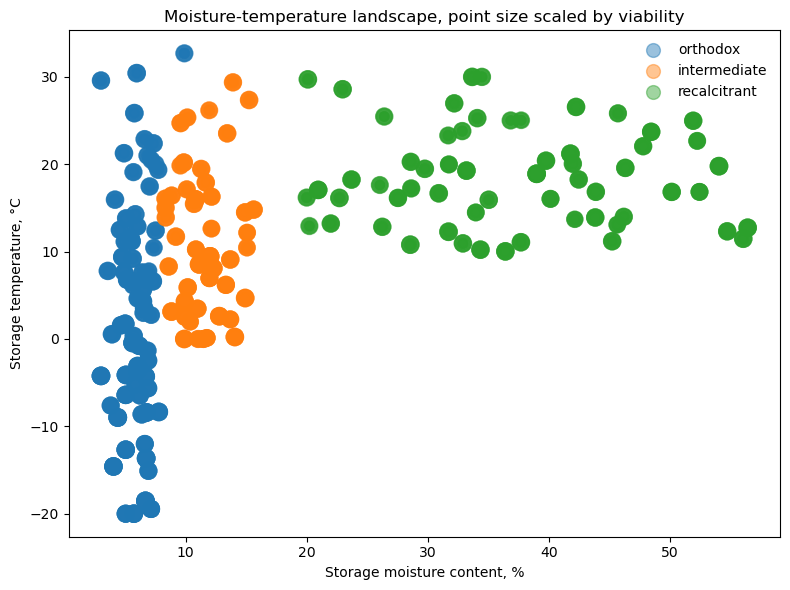

In [19]:
fig, ax = plt.subplots(figsize=(8, 6))
for cat in ["orthodox", "intermediate", "recalcitrant"]:
    sub = df[df["category"] == cat]
    ax.scatter(sub["storage_moisture_pct"], sub["storage_temp_c"], s=40 + 120 * sub["viability_prob"], alpha=0.45, label=cat)
ax.set_xlabel("Storage moisture content, %")
ax.set_ylabel("Storage temperature, °C")
ax.set_title("Moisture-temperature landscape, point size scaled by viability")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(FIGDIR / "figure_moisture_temperature_landscape.png", dpi=300, bbox_inches="tight")
plt.show()

## Survival-style endpoint construction

Here, the event is defined as viability below 0.50, which approximates the classical P50 idea used in seed longevity work.

In [22]:
model_df = df.copy()
model_df["event_viability_below_50"] = (model_df["viability_prob"] < 0.50).astype(int)
model_df["event_germination_below_50"] = (model_df["germination_prob"] < 0.50).astype(int)
model_df["event_high_dormancy"] = (model_df["dormancy_prob"] > 0.40).astype(int)

features = [
    "species", "category", "month", "storage_years",
    "initial_viability", "primary_dormancy", "seed_fill_stress",
    "mechanical_damage", "fungal_pressure",
    "storage_moisture_pct", "storage_temp_c", "oxygen_level",
    "package_type", "water_activity", "critical_moisture_pct"
]
target = "event_viability_below_50"

X = model_df[features].copy()
y = model_df[target].copy()
groups = model_df["lot_id"].copy()

cat_cols = ["species", "category", "oxygen_level", "package_type"]
num_cols = [c for c in features if c not in cat_cols]

preprocess = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), num_cols),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("onehot", OneHotEncoder(handle_unknown="ignore"))]), cat_cols)
])

splitter = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(splitter.split(X, y, groups=groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
print(X_train.shape, X_test.shape)

(1080, 15) (360, 15)


## Model 1, baseline discrete-time hazard classifier

In [25]:
hazard_model = Pipeline([
    ("prep", preprocess),
    ("clf", LogisticRegression(max_iter=2000))
])

hazard_model.fit(X_train, y_train)
p_test_hazard = hazard_model.predict_proba(X_test)[:, 1]

hazard_metrics = pd.DataFrame([{
    "model": "discrete_time_logistic",
    "auroc": roc_auc_score(y_test, p_test_hazard),
    "auprc": average_precision_score(y_test, p_test_hazard),
    "brier": brier_score_loss(y_test, p_test_hazard),
    "log_loss": log_loss(y_test, p_test_hazard),
}]).round(4)

hazard_metrics.to_csv(TABDIR / "table_3_hazard_model_metrics.csv", index=False)
hazard_metrics

,model,auroc,auprc,brier,log_loss
0,discrete_time_logistic,0.958,0.9116,0.0748,0.237


## Model 2, mechanistic baseline for continuous viability

This baseline predicts continuous viability probability from a manually constructed deterioration index.

In [28]:
def mechanistic_baseline(frame):
    f = frame.copy()
    cat_orth = (f["category"] == "orthodox").astype(float)
    cat_int = (f["category"] == "intermediate").astype(float)
    cat_rec = (f["category"] == "recalcitrant").astype(float)

    oxygen_score = f["oxygen_level"].map({"anoxic": -0.25, "low": -0.12, "ambient": 0.0, "high": 0.20}).astype(float)
    package_score = f["package_type"].map({"foil_hermetic": -0.10, "jar_hermetic": -0.05, "paper": 0.10, "laminate": 0.02}).astype(float)

    recalc_desiccation = np.where(cat_rec > 0, np.maximum(f["critical_moisture_pct"].fillna(0) - f["storage_moisture_pct"], 0) / 10.0, 0.0)
    int_desiccation = np.where(cat_int > 0, np.maximum(10.0 - f["storage_moisture_pct"], 0) / 8.0, 0.0)
    orthodox_mc_penalty = np.where(cat_orth > 0, np.maximum(f["storage_moisture_pct"] - 7.0, 0) / 10.0, 0.0)

    index = (
        2.1 + 2.0 * (f["initial_viability"] - 0.9) - 0.22 * f["storage_years"]
        - 0.035 * np.maximum(f["storage_temp_c"] + 5, 0) - 0.030 * orthodox_mc_penalty
        - 0.22 * int_desiccation - 0.45 * recalc_desiccation - 0.55 * f["fungal_pressure"]
        - 0.45 * f["mechanical_damage"] - 0.35 * f["seed_fill_stress"]
        - 0.30 * np.maximum(f["water_activity"] - 0.70, 0) - oxygen_score - package_score
    )
    return logistic(index)

baseline_train = mechanistic_baseline(X_train)
baseline_test = mechanistic_baseline(X_test)
y_train_cont = model_df.iloc[train_idx]["viability_prob"].values
y_test_cont = model_df.iloc[test_idx]["viability_prob"].values

baseline_reg_metrics = pd.DataFrame([{
    "model": "mechanistic_baseline",
    "mae_test": mean_absolute_error(y_test_cont, baseline_test),
    "rmse_test": mean_squared_error(y_test_cont, baseline_test) ** 0.5,
    "r2_test": r2_score(y_test_cont, baseline_test),
}]).round(4)

baseline_reg_metrics.to_csv(TABDIR / "table_4_mechanistic_baseline_metrics.csv", index=False)
baseline_reg_metrics

,model,mae_test,rmse_test,r2_test
0,mechanistic_baseline,0.1778,0.2135,0.5715


## Model 3, hybrid residual learner

In [31]:
residual_train = y_train_cont - baseline_train

resid_model = Pipeline([
    ("prep", preprocess),
    ("gbr", GradientBoostingRegressor(random_state=42))
])

resid_model.fit(X_train, residual_train)
resid_pred_test = resid_model.predict(X_test)
hybrid_pred_test = np.clip(baseline_test + resid_pred_test, 0, 1)

hybrid_metrics = pd.DataFrame([{
    "model": "hybrid_mechanistic_plus_gbr",
    "mae_test": mean_absolute_error(y_test_cont, hybrid_pred_test),
    "rmse_test": mean_squared_error(y_test_cont, hybrid_pred_test) ** 0.5,
    "r2_test": r2_score(y_test_cont, hybrid_pred_test),
}]).round(4)

hybrid_metrics.to_csv(TABDIR / "table_5_hybrid_model_metrics.csv", index=False)
hybrid_metrics

,model,mae_test,rmse_test,r2_test
0,hybrid_mechanistic_plus_gbr,0.085,0.119,0.8668


## Compare baseline and hybrid predictions

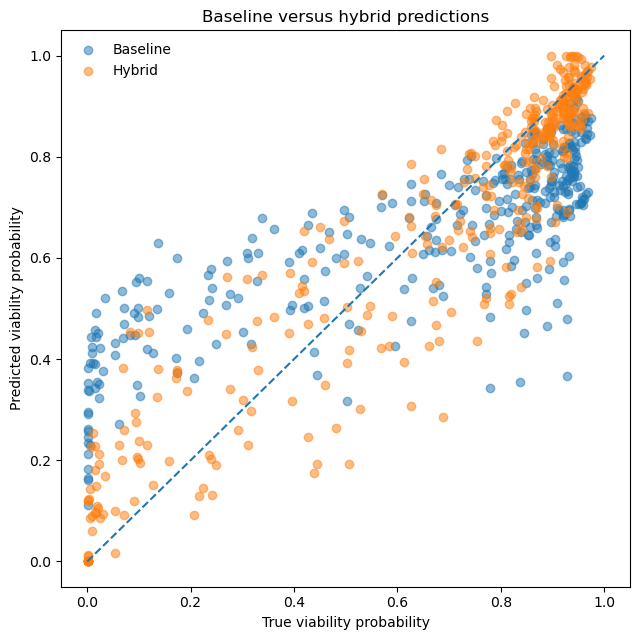

In [34]:
compare_df = pd.DataFrame({
    "true_viability": y_test_cont,
    "baseline_pred": baseline_test,
    "hybrid_pred": hybrid_pred_test,
    "category": X_test["category"].values
})

fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.scatter(compare_df["true_viability"], compare_df["baseline_pred"], alpha=0.5, label="Baseline")
ax.scatter(compare_df["true_viability"], compare_df["hybrid_pred"], alpha=0.5, label="Hybrid")
ax.plot([0, 1], [0, 1], linestyle="--")
ax.set_xlabel("True viability probability")
ax.set_ylabel("Predicted viability probability")
ax.set_title("Baseline versus hybrid predictions")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(FIGDIR / "figure_baseline_vs_hybrid_predictions.png", dpi=300, bbox_inches="tight")
plt.show()

## Risk calibration for the hazard model

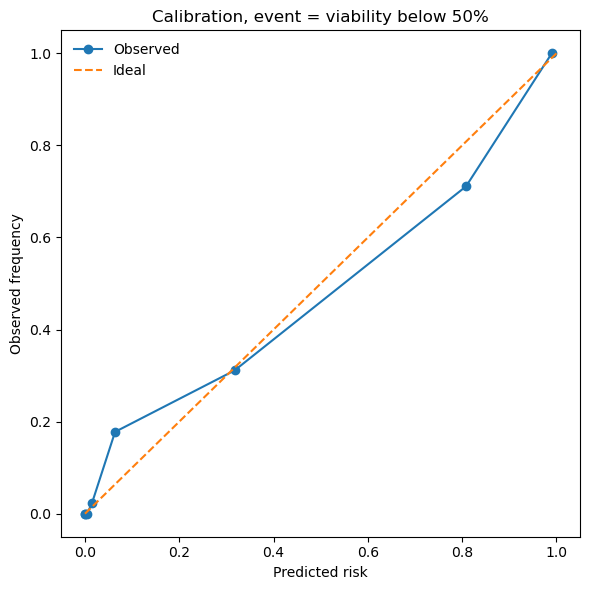

In [37]:
frac_pos, mean_pred = calibration_curve(y_test, p_test_hazard, n_bins=8, strategy="quantile")
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(mean_pred, frac_pos, marker="o", label="Observed")
ax.plot([0, 1], [0, 1], linestyle="--", label="Ideal")
ax.set_xlabel("Predicted risk")
ax.set_ylabel("Observed frequency")
ax.set_title("Calibration, event = viability below 50%")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(FIGDIR / "figure_hazard_calibration.png", dpi=300, bbox_inches="tight")
plt.show()

## Approximate feature importance

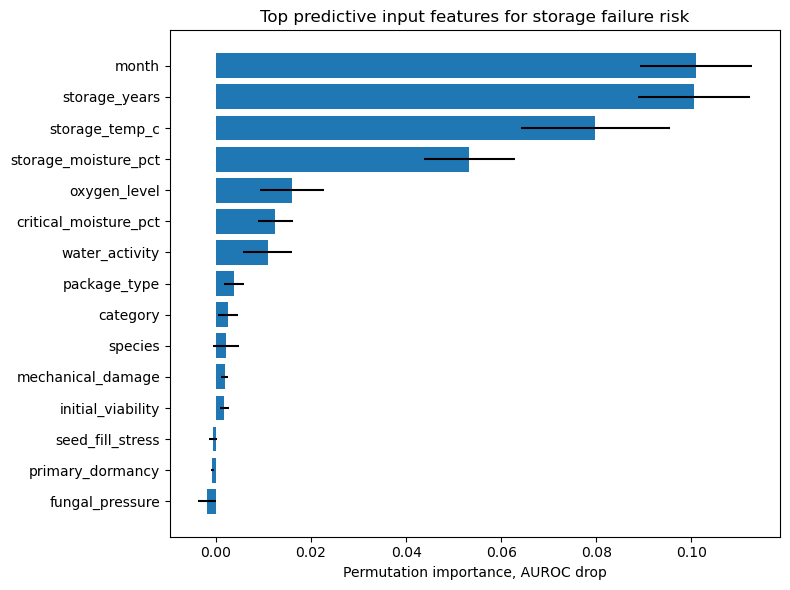

,feature,importance_mean,importance_std
2,month,0.101031,0.011831
3,storage_years,0.100563,0.011771
10,storage_temp_c,0.079862,0.015702
9,storage_moisture_pct,0.053338,0.009661
11,oxygen_level,0.015958,0.006701
14,critical_moisture_pct,0.012492,0.003656
13,water_activity,0.010827,0.005175
12,package_type,0.003862,0.002106
1,category,0.002481,0.002042
0,species,0.002062,0.002660


In [40]:
# Permutation importance should be aligned to the original input columns, not the one-hot expanded columns.
# Because permutation_importance is applied to the full pipeline, each importance score corresponds to one column in X_test.

perm = permutation_importance(
    hazard_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="roc_auc"
)

feature_names = list(X_test.columns)

imp_df = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

imp_df.to_csv(TABDIR / "table_6_permutation_importance.csv", index=False)

top_imp = imp_df.head(min(15, len(imp_df))).sort_values("importance_mean")
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top_imp["feature"], top_imp["importance_mean"], xerr=top_imp["importance_std"])
ax.set_xlabel("Permutation importance, AUROC drop")
ax.set_title("Top predictive input features for storage failure risk")
fig.tight_layout()
fig.savefig(FIGDIR / "figure_permutation_importance.png", dpi=300, bbox_inches="tight")
plt.show()

imp_df.head(10)


## Lot-level survival summary

In [43]:
lot_failure = (
    model_df[model_df["event_viability_below_50"] == 1]
    .groupby("lot_id")["month"]
    .min()
    .rename("first_month_below_50")
    .reset_index()
)
lot_surv = lots.merge(lot_failure, on="lot_id", how="left")
lot_surv["first_month_below_50"] = lot_surv["first_month_below_50"].fillna(model_df["month"].max() + 12)
lot_surv["failed_within_observation"] = (lot_surv["first_month_below_50"] <= model_df["month"].max()).astype(int)
lot_surv.to_csv(TABDIR / "table_7_lot_level_failure_summary.csv", index=False)
lot_surv.groupby("category")[["first_month_below_50", "failed_within_observation"]].agg(["mean", "median"]).round(2)

first_month_below_50        failed_within_observation       
                             mean median                      mean median
category                                                                 
intermediate                64.60   60.0                      0.81    1.0
orthodox                    64.54   60.0                      0.68    1.0
recalcitrant                45.56   36.0                      0.97    1.0

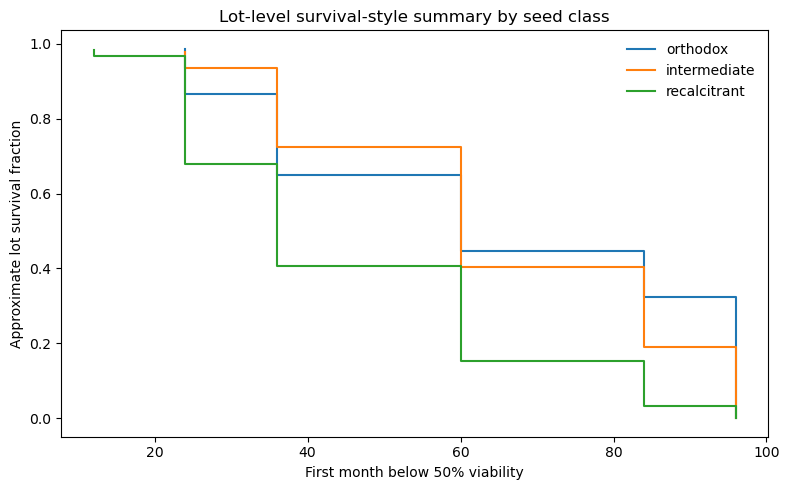

In [45]:
fig, ax = plt.subplots(figsize=(8, 5))
for cat in ["orthodox", "intermediate", "recalcitrant"]:
    sub = lot_surv[lot_surv["category"] == cat].sort_values("first_month_below_50")
    yline = 1 - np.arange(1, len(sub) + 1) / len(sub)
    ax.step(sub["first_month_below_50"], yline, where="post", label=cat)
ax.set_xlabel("First month below 50% viability")
ax.set_ylabel("Approximate lot survival fraction")
ax.set_title("Lot-level survival-style summary by seed class")
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(FIGDIR / "figure_lot_survival_summary.png", dpi=300, bbox_inches="tight")
plt.show()

## Scenario analysis

In [48]:
scenario = pd.DataFrame([
    {
        "species": "rice", "category": "orthodox", "month": 36, "storage_years": 3.0,
        "initial_viability": 0.96, "primary_dormancy": 0.18, "seed_fill_stress": 0.12,
        "mechanical_damage": 0.05, "fungal_pressure": 0.04, "storage_moisture_pct": mc,
        "storage_temp_c": temp, "oxygen_level": oxy, "package_type": pkg,
        "water_activity": aw, "critical_moisture_pct": np.nan,
    }
    for mc, temp, oxy, pkg, aw in [
        (5.0, -20.0, "anoxic", "foil_hermetic", 0.28),
        (6.0, 5.0, "low", "jar_hermetic", 0.34),
        (8.0, 20.0, "ambient", "paper", 0.52),
        (9.0, 30.0, "high", "paper", 0.66),
    ]
])
scenario["baseline_viability"] = mechanistic_baseline(scenario)
scenario["risk_viability_below_50"] = hazard_model.predict_proba(scenario[features])[:, 1]
scenario = scenario.round(4)
scenario.to_csv(TABDIR / "table_8_scenario_analysis.csv", index=False)
scenario

,species,category,month,storage_years,initial_viability,primary_dormancy,seed_fill_stress,mechanical_damage,fungal_pressure,storage_moisture_pct,storage_temp_c,oxygen_level,package_type,water_activity,critical_moisture_pct,baseline_viability,risk_viability_below_50
0,rice,orthodox,36,3.0,0.96,0.18,0.12,0.05,0.04,5.0,-20.0,anoxic,foil_hermetic,0.28,NaN,0.8610,0.0000
1,rice,orthodox,36,3.0,0.96,0.18,0.12,0.05,0.04,6.0,5.0,low,jar_hermetic,0.34,NaN,0.7847,0.0045
2,rice,orthodox,36,3.0,0.96,0.18,0.12,0.05,0.04,8.0,20.0,ambient,paper,0.52,NaN,0.6214,0.7483
3,rice,orthodox,36,3.0,0.96,0.18,0.12,0.05,0.04,9.0,30.0,high,paper,0.66,NaN,0.4856,0.9918


## Interpretation notes

The synthetic analysis should show that orthodox lots usually perform best at low moisture and low temperature, consistent with classical storage theory. Recalcitrant lots suffer when moisture falls below their safe zone, which means that a strategy that helps orthodox seeds may actively damage recalcitrant seeds. Dormancy can transiently inflate the difference between viability and germination. Oxygen and packaging matter, especially when storage is not fully controlled.

## Limitations

This notebook is a proof of concept. The dataset is simulated, not experimental. The coefficients are literature-guided but not estimated from any one real multi-species database. For real deployment, the next steps would be to fit a Bayesian hierarchical survival model to true longitudinal lot data, use explicit oxygen and water-activity histories rather than static proxies, and calibrate separate observation models for germination, tetrazolium viability, and dormancy-release assays.

## Compact reference list used to benchmark the simulation

Ellis, R. H., and Roberts, E. H. developed the seed viability equations and the classical storage framework.

Hay, F. R., Rezaei, S., and Buitink, J. reviewed seed moisture isotherms, sorption models, and longevity.

Solberg, S. Ø., Yndgaard, F., Andreasen, C., von Bothmer, R., Loskutov, I. G., and Asdal, Å. summarised long-term storage and longevity of orthodox seeds.

Reed, R. C., Bradford, K. J., and Khanday, I. reviewed seed germination, vigor, dormancy, and climate interactions.

Hong, T. D., and Ellis, R. H. provided a widely used protocol to determine seed storage behaviour.

Groot, S. P. C., Surki, A. A., de Vos, R. C. H., and Kodde, J. showed that elevated oxygen pressure accelerates dry seed ageing.

Groot, S. P. C., de Groot, L., Kodde, J., and van Treuren, R. reported benefits of storage under anoxia for ex situ conserved seeds.

Roberts, E. H., and Ellis, R. H. discussed water and seed survival, especially the contrast between orthodox and recalcitrant seeds.

De Vitis, M., Hay, F. R., Dickie, J. B., Trivedi, C., Choi, J., and Fiegener, R. reviewed seed storage practice and seed viability maintenance for restoration and conservation.

Selected source links used in this notebook build:
- https://pmc.ncbi.nlm.nih.gov/articles/PMC9201756/
- https://pmc.ncbi.nlm.nih.gov/articles/PMC6204563/
- https://pmc.ncbi.nlm.nih.gov/articles/PMC7347988/
- https://pmc.ncbi.nlm.nih.gov/articles/PMC9177656/
- https://www.cbd.int/doc/case-studies/tttc/seedstorage.pdf
- https://pmc.ncbi.nlm.nih.gov/articles/PMC3478056/
- https://www.cambridge.org/core/journals/plant-genetic-resources/article/prolonging-the-longevity-of-ex-situ-conserved-seeds-by-storage-under-anoxia/9708026C5DD8D842FEDCD5EF7F5577AD
- https://agris.fao.org/search/en/providers/122535/records/65dec4bf0f3e94b9e5d1186b
- https://agris.fao.org/search/en/providers/122575/records/669f69b3a4dac527f930c39f

In [53]:
exports = []
for p in sorted(FIGDIR.glob("*")):
    exports.append({"type": "figure", "file": str(p)})
for p in sorted(TABDIR.glob("*")):
    exports.append({"type": "table", "file": str(p)})

manifest = pd.DataFrame(exports)
manifest.to_csv(OUTDIR / "export_manifest.csv", index=False)
manifest

,type,file
0,figure,/Users/petalc01/ARIA Recalcitrant Seeds/seed_v...
1,figure,/Users/petalc01/ARIA Recalcitrant Seeds/seed_v...
2,figure,/Users/petalc01/ARIA Recalcitrant Seeds/seed_v...
3,figure,/Users/petalc01/ARIA Recalcitrant Seeds/seed_v...
4,figure,/Users/petalc01/ARIA Recalcitrant Seeds/seed_v...
5,figure,/Users/petalc01/ARIA Recalcitrant Seeds/seed_v...
6,figure,/Users/petalc01/ARIA Recalcitrant Seeds/seed_v...
7,figure,/Users/petalc01/ARIA Recalcitrant Seeds/seed_v...
8,table,/Users/petalc01/ARIA Recalcitrant Seeds/seed_v...
9,table,/Users/petalc01/ARIA Recalcitrant Seeds/seed_v...
